### Business Problem: Optimizing Loan Portfolio Profitability While Minimizing Risk Exposure
Background:
A financial institution wants to grow its loan portfolio by approving more applications without significantly increasing its default risk. Historically, overly cautious approval strategies have led to lost revenue opportunities, while lenient strategies have increased default rates and write-offs.

#### Objective:
Use predictive modeling to identify applicants who are both **likely to repay their loans and profitable to approve**, balancing approval rates with financial risk and expected returns.

#### Key Question to Address:
<!-- ##### I] Risk Assessment (Regression Task)

1) What is the predicted RiskScore for a new applicant, indicating the likelihood of default?

2) How does this score correlate with key variables like credit history, debt-to-income ratio, or loan purpose? -->

**Loan Approval (Classification Task)**  - Should this applicant be approved or denied for a loan based on their financial profile?

<!-- ##### Strategic Decisioning

1) How can we segment applicants (e.g., low-risk/high-value, high-risk/low-value) to refine lending strategies?

2) What threshold on the RiskScore corresponds to optimal approval criteria (balancing profit vs. risk)? -->


### Loan Approval Prediction

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
# !pip3 install xgboost
import xgboost as xgb

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import pickle

#### Understanding the dataset

In [2]:
# Reading the dataset
df = pd.read_csv("Loan.csv")

In [4]:
df.head(2)

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0


In [3]:
df.shape

(20000, 36)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

So we have around 20000 records and 36 attributes. We can see that no column contains null values.      
Let us now identify and calculate some metrics from the above columns so that we can drop the columns that are not required after calculating the metrics.

**-------- CALCULATED METRICS --------**


**P** = Loan Amount,    
**r** = Interest Rate (NOT Base Interest Rate),     
**n** = Loan Duration in Month       
**Monthly Loan Amount** = P * r * (1 + r)^n / ((1 + r)^n - 1)



**Net worth** = Total Assets - Total Liabilities



**AnnualIncome** = MonthlyIncome * 12



**DebtToIncomeRatio** = MonthlyDebtPayment / MonthlyIncome



**InterestRate** = BaseInterestRate + Margin



**Monthly_LoanToIncomeRatio** = MonthlyLoanAmount / MonthlyIncome



In [3]:
print("Original Shape of Dataset")
df.shape

Original Shape of Dataset


(20000, 36)

In [4]:
# Dropping column to correctly calculate the metric
df.drop(columns=['DebtToIncomeRatio'], axis=1, inplace=True)

In [5]:
# Calculate Debt to Income Ratio (using monthly income and debt amounts)
df['DebtToIncomeRatio'] = df['MonthlyDebtPayments']/df['MonthlyIncome']
df['Monthly_LoanToIncomeRatio'] = df['MonthlyLoanPayment']/df['MonthlyIncome']

In [6]:
# Dropping unnecessary columns
df.drop(columns=[
    'TotalDebtToIncomeRatio',
    'AnnualIncome', 
    'LoanAmount',
    'LoanDuration',
    'MonthlyDebtPayments',
    'MonthlyIncome',
    'BaseInterestRate',
    'InterestRate',
    'MonthlyLoanPayment',
    'TotalAssets',
    'TotalLiabilities'
    ], axis=1, inplace=True)

In [7]:
print("Shape of Dataset after removing Unnecessary Columns")
df.shape

Shape of Dataset after removing Unnecessary Columns


(20000, 26)

We can see that we were able to shorten the dataset by 10 columns.

##### Cleaning Application Date Column

The reason why we are cleaning this column is it will allow us to perform time series analysis on the application data. We can skip this step and drop the column if we are mainly concerned about prediting whether a loan application will be approved or declined.

In [6]:
# Converting the date column to datetime
df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'])

# Extracting Year and Month from Application Date (this will be useful to perform trend analysis)
df['ApplicationYear'] = df['ApplicationDate'].dt.year
df['ApplicationMonth'] = df['ApplicationDate'].dt.month

In [14]:
df[['ApplicationDate', 'ApplicationYear', 'ApplicationMonth']].head(2)

,ApplicationDate,ApplicationYear,ApplicationMonth
0,2018-01-01,2018,1
1,2018-01-02,2018,1


In [7]:
# Revising the Application date column
# df = df[~df['ApplicationYear'].isin([2067, 2068, 2069, 2070, 2071, 2072])]

conditions = [
    ((df['ApplicationYear'] >= 2025) & (df['ApplicationYear'] <= 2031)) | (df['ApplicationYear'] == 2018),
    ((df['ApplicationYear'] >= 2032) & (df['ApplicationYear'] <= 2038)) | (df['ApplicationYear'] == 2019),
    ((df['ApplicationYear'] >= 2039) & (df['ApplicationYear'] <= 2045)) | (df['ApplicationYear'] == 2020),
    ((df['ApplicationYear'] >= 2046) & (df['ApplicationYear'] <= 2052)) | (df['ApplicationYear'] == 2021),
    ((df['ApplicationYear'] >= 2053) & (df['ApplicationYear'] <= 2059)) | (df['ApplicationYear'] == 2022),
    ((df['ApplicationYear'] >= 2060) & (df['ApplicationYear'] <= 2066)) | (df['ApplicationYear'] == 2023),
    (df['ApplicationYear'] >= 2067) | (df['ApplicationYear'] == 2024)
    ]

replacemet_years = [2018, 2019, 2020, 2021, 2022, 2023, 2024]

df['ApplicationYear'] = np.select(conditions, replacemet_years)

In [8]:
df['ApplicationYear'].value_counts().sort_index()

ApplicationYear
2018    2921
2019    2922
2020    2923
2021    2922
2022    2921
2023    2922
2024    2469
Name: count, dtype: int64

In [8]:
# Dropping the Application date column
df.drop(columns = ['ApplicationDate'], inplace=True)

Now let us group the columns by their datatypes to get a better understanding of what kind of data are we dealing with.     
This will help us during the encoding and scaling stage.    
For now, I have decided to drop the Application Date column and focus on the modelling and predictions.

In [8]:
# Grouping the columns by the datatype
col = df.columns.to_series().groupby(df.dtypes).groups

col2 = {k.name: v.tolist() for k, v in col.items()}

In [9]:
col2

{'int64': ['Age',
  'CreditScore',
  'Experience',
  'NumberOfDependents',
  'NumberOfOpenCreditLines',
  'NumberOfCreditInquiries',
  'BankruptcyHistory',
  'PreviousLoanDefaults',
  'PaymentHistory',
  'LengthOfCreditHistory',
  'SavingsAccountBalance',
  'CheckingAccountBalance',
  'JobTenure',
  'NetWorth',
  'LoanApproved'],
 'float64': ['CreditCardUtilizationRate',
  'UtilityBillsPaymentHistory',
  'RiskScore',
  'DebtToIncomeRatio',
  'Monthly_LoanToIncomeRatio'],
 'object': ['EmploymentStatus',
  'EducationLevel',
  'MaritalStatus',
  'HomeOwnershipStatus',
  'LoanPurpose']}

We can see that we mainly have 3 types of data - integer, float and object (non-numeric). So now we know that the data that we have to encode belong to the object type.

In [10]:
# rounding to 3 decimal places
df['UtilityBillsPaymentHistory'] = df['UtilityBillsPaymentHistory'].round(decimals=3)

In [ ]:
# check for null values, just to make sure there aren't any
df.isnull().sum()

Age                           0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
LoanApproved                  0
RiskScore                     0
DebtToIncomeRatio             0
Monthly_LoanToIncomeRatio     0
dtype: int64

#### Correlating Attributes

Before we move to Encode and Normalize our data, let us check how do the attributed correlate to the target variable 'LoanApproved'.    
I am creating a copy of the dataframe and temporarily encoding the non numeric values to check the correlation. 

In [9]:
df_corr = df.copy()

In [10]:
encoder = OrdinalEncoder()

categorical_cols = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']
df_corr[categorical_cols] = encoder.fit_transform(df_corr[categorical_cols])

In [11]:
grp = df_corr.columns.to_series().groupby(df_corr.dtypes).groups

grps = {k.name: v.to_list() for k, v in grp.items()}

In [12]:
grps

{'int64': ['Age',
  'CreditScore',
  'Experience',
  'NumberOfDependents',
  'NumberOfOpenCreditLines',
  'NumberOfCreditInquiries',
  'BankruptcyHistory',
  'PreviousLoanDefaults',
  'PaymentHistory',
  'LengthOfCreditHistory',
  'SavingsAccountBalance',
  'CheckingAccountBalance',
  'JobTenure',
  'NetWorth',
  'LoanApproved'],
 'float64': ['EmploymentStatus',
  'EducationLevel',
  'MaritalStatus',
  'HomeOwnershipStatus',
  'CreditCardUtilizationRate',
  'LoanPurpose',
  'UtilityBillsPaymentHistory',
  'RiskScore',
  'DebtToIncomeRatio',
  'Monthly_LoanToIncomeRatio']}

We can see that we are left with datatypes that are numeric. The column having the object datatype are now converted to integer datatype.       
The change in the columns can be seen when we compare the dataframes below.

In [56]:
df.head()

,Age,CreditScore,EmploymentStatus,EducationLevel,Experience,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,UtilityBillsPaymentHistory,JobTenure,NetWorth,LoanApproved,RiskScore,DebtToIncomeRatio,Monthly_LoanToIncomeRatio
0,45,617,Employed,Master,22,Married,2,Own,0.354418,1,...,9,7632,1202,0.724972,11,126928,0,49.0,0.054971,0.126106
1,38,628,Employed,Associate,15,Single,1,Mortgage,0.087827,5,...,9,4627,3460,0.935132,3,43609,0,52.0,0.149890,0.239962
2,47,570,Employed,Bachelor,26,Married,2,Rent,0.137414,2,...,22,886,895,0.872241,6,5205,0,52.0,0.265789,0.196368
3,58,545,Employed,High School,34,Single,1,Mortgage,0.267587,2,...,10,1675,1217,0.896155,5,99452,0,54.0,0.131145,0.181954
4,37,594,Employed,Associate,17,Married,1,Mortgage,0.320535,0,...,27,1555,4981,0.941369,5,227019,1,36.0,0.031841,0.038369


In [55]:
df_corr.head()

,Age,CreditScore,EmploymentStatus,EducationLevel,Experience,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,UtilityBillsPaymentHistory,JobTenure,NetWorth,LoanApproved,RiskScore,DebtToIncomeRatio,Monthly_LoanToIncomeRatio
0,45,617,0.0,4.0,22,1.0,2,2.0,0.354418,1,...,9,7632,1202,0.724972,11,126928,0,49.0,0.054971,0.126106
1,38,628,0.0,0.0,15,2.0,1,0.0,0.087827,5,...,9,4627,3460,0.935132,3,43609,0,52.0,0.149890,0.239962
2,47,570,0.0,1.0,26,1.0,2,3.0,0.137414,2,...,22,886,895,0.872241,6,5205,0,52.0,0.265789,0.196368
3,58,545,0.0,3.0,34,2.0,1,0.0,0.267587,2,...,10,1675,1217,0.896155,5,99452,0,54.0,0.131145,0.181954
4,37,594,0.0,0.0,17,1.0,1,0.0,0.320535,0,...,27,1555,4981,0.941369,5,227019,1,36.0,0.031841,0.038369


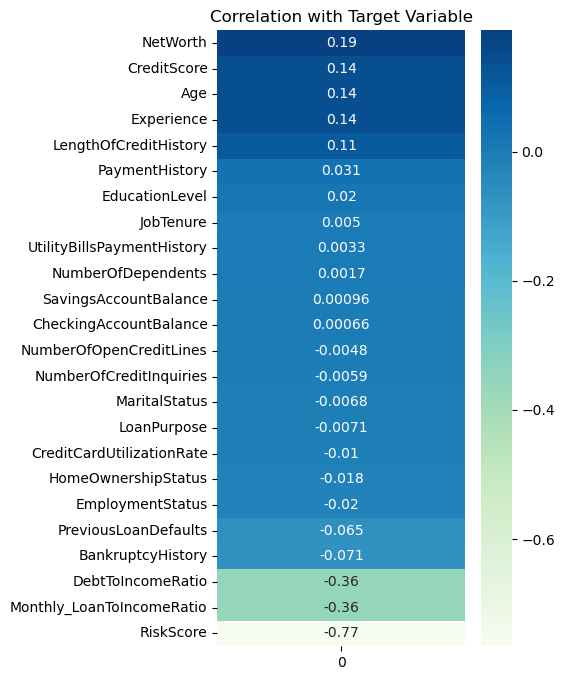

In [13]:
features = df_corr.drop(columns=['LoanApproved'], axis = 1)
target = df_corr['LoanApproved']


# Create a correlation matrix with target variable
corr_with_target = features.corrwith(target)

# Sort features by correlation with target variable
corr_with_target = corr_with_target.sort_values(ascending=False)

# Plot the heatmap
plt.figure(figsize=(4, 8))
sns.heatmap(corr_with_target.to_frame(), cmap='GnBu', annot=True)
plt.title('Correlation with Target Variable')
plt.show()

The heatmap structure helps us identify the magnitude of correlation with the target variable. If we take a look at the ends we notice that the following columns play a significant role in determining whether the loan is approved or rejected: 
     
(having positive correlation) 'NetWorth', 'CreditScore', 'Age', 'Experience', 'LengthOfCreditHistory'   
(having negative correlation) 'DebtToIncomeRatio', 'Monthly_LoanToIncomeRatio', 'RiskScore'

In [14]:
df_subset = df[['CreditScore', 'Age', 'Experience', 'NetWorth', 'LengthOfCreditHistory', 'DebtToIncomeRatio', 'Monthly_LoanToIncomeRatio', 'RiskScore', 'LoanApproved']]

In [15]:
df_subset.head()

,CreditScore,Age,Experience,NetWorth,LengthOfCreditHistory,DebtToIncomeRatio,Monthly_LoanToIncomeRatio,RiskScore,LoanApproved
0,617,45,22,126928,9,0.054971,0.126106,49.0,0
1,628,38,15,43609,9,0.149890,0.239962,52.0,0
2,570,47,26,5205,22,0.265789,0.196368,52.0,0
3,545,58,34,99452,10,0.131145,0.181954,54.0,0
4,594,37,17,227019,27,0.031841,0.038369,36.0,1


##### Some other Feature Selection methods using heatmap

In [ ]:
#-------------------------------------------------------------

from sklearn.feature_selection import RFE, FSSearch, SelectKBest, chi2
from sklearn.linear_model import LogisticRegression

# Load the dataset
X = ... # features
y = ... # target

# Create a logistic regression model
model = LogisticRegression()

"""
Recursive Feature Elimination (RFE) is a feature selection technique that involves training a model on a subset of the features, 
and then iteratively removing the least important features one by one until we are left with the desired number of features.
"""

# Use RFE to select the top 10 features
rfe = RFE(model, n_features_to_select=10)
rfe.fit(X, y)

# Print the selected features
print(rfe.support_)

"""
“Forward Selection”, which involves starting with an empty set of features and iteratively adding one feature at a time until the 
desired number of features is reached. At each step, the model is trained and evaluated, and the feature that results in the greatest 
improvement in performance is added to the set.
"""

# Use FSSearch to select the top 10 features
fs = FSSearch(model, scoring='accuracy')
fs.fit(X, y)

# Print the selected features
print(fs.best_idx_)


"""
Filter approach to feature selection involves using statistical tests or heuristics to select the most relevant features for a predictive model. 
The goal is to select features that are highly correlated with the target variable, as these are likely to be the most useful for prediction.
"""

# Use SelectKBest to select the top 10 features
selector = SelectKBest(chi2, k=10)
X_new = selector.fit_transform(X, y)

# Print the selected features
print(selector.get_support())
#-------------------------------------------------------------

#### Train Test Split

In [16]:
# Creating train, validation and test datasets

X = df_subset.drop(columns=['LoanApproved'], axis=1)
y = df_subset['LoanApproved']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val,X_test, y_val,y_test = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

In [17]:
X_train.head(1)

,CreditScore,Age,Experience,NetWorth,LengthOfCreditHistory,DebtToIncomeRatio,Monthly_LoanToIncomeRatio,RiskScore
17763,511,57,35,34306,25,0.183901,0.388267,51.0


In [18]:
y_train.head(1)

17763    0
Name: LoanApproved, dtype: int64

#### Checking the proportion of rejected and approved loan applications

In [ ]:
# Converting numpy series to dataframes
column_headers = df_subset.columns.to_list()
X_train = pd.DataFrame(X_train, columns=column_headers[-(len(column_headers)):-1])
y_train = pd.DataFrame(y_train, columns=['LoanApproved'])

In [ ]:
# Checking how many loan applications are approved
print(len(y_train[y_train['LoanApproved'] == 1]))

2868


#### Encoding and Scaling

In [ ]:
# Encoding
encoder = OrdinalEncoder()

# Let's say these are your categorical columns
categorical_cols = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']

encoder.fit(X_train[categorical_cols])
X_train[categorical_cols] = encoder.transform(X_train[categorical_cols])
X_val[categorical_cols] = encoder.transform(X_val[categorical_cols])
X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])

In [22]:
for col, categories in zip(categorical_cols, encoder.categories_):
    print(f"Mapping for '{col}':")
    for i, cat in enumerate(categories):
        print(f"  {cat} --> {i}")
    print()

Mapping for 'EmploymentStatus':
  Employed --> 0
  Self-Employed --> 1
  Unemployed --> 2

Mapping for 'EducationLevel':
  Associate --> 0
  Bachelor --> 1
  Doctorate --> 2
  High School --> 3
  Master --> 4

Mapping for 'MaritalStatus':
  Divorced --> 0
  Married --> 1
  Single --> 2
  Widowed --> 3

Mapping for 'HomeOwnershipStatus':
  Mortgage --> 0
  Other --> 1
  Own --> 2
  Rent --> 3

Mapping for 'LoanPurpose':
  Auto --> 0
  Debt Consolidation --> 1
  Education --> 2
  Home --> 3
  Other --> 4



In [ ]:
# RobustScaler is less prone to outliers.
rb_scaler = RobustScaler()

rb_scaler.fit(X_train)
X_train = rb_scaler.transform(X_train)
X_val = rb_scaler.transform(X_val)
X_test = rb_scaler.transform(X_test)

In [72]:
pd.DataFrame(X_train).head()

,Age,CreditScore,EmploymentStatus,EducationLevel,Experience,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,UtilityBillsPaymentHistory,JobTenure,NetWorth,RiskScore,DebtToIncomeRatio,Monthly_LoanToIncomeRatio
17763,57,511,Employed,Master,35,Single,2,Rent,0.363811,2,...,21,25,5801,5246,0.714049,2,34306,51.0,0.183901,0.388267
3364,31,587,Employed,High School,6,Single,4,Mortgage,0.478811,2,...,20,22,5297,722,0.720363,6,95930,50.0,0.082409,0.347455
3134,40,609,Employed,High School,18,Married,4,Mortgage,0.159431,1,...,17,10,7148,784,0.722829,2,36259,53.0,0.071017,0.093312
7992,59,666,Employed,Bachelor,36,Single,0,Mortgage,0.292295,2,...,15,14,2732,7033,0.906780,3,72339,33.6,0.023281,0.029315
2936,32,574,Employed,Doctorate,12,Married,1,Mortgage,0.187842,1,...,27,22,4482,3781,0.703866,4,9862,53.0,0.119505,0.270500


#### Random Under Sampling

Let's check the proportion of Loans Applications approved and rejected in the **entire dataset**

In [ ]:
print(f"Loan Requests Approved: {df_subset[df_subset['LoanApproved']==1].shape[0]}/{df_subset.shape[0]}  =  {df_subset[df_subset['LoanApproved']==1].shape[0] / df_subset.shape[0] * 100}%")
print(f"Loan Requests Rejected: {df_subset[df_subset['LoanApproved']==0].shape[0]}/{df_subset.shape[0]}  =  {df_subset[df_subset['LoanApproved']==0].shape[0] / df_subset.shape[0] * 100}%")

Loan Requests Approved: 4780/20000  =  23.9%
Loan Requests Rejected: 15220/20000  =  76.1%


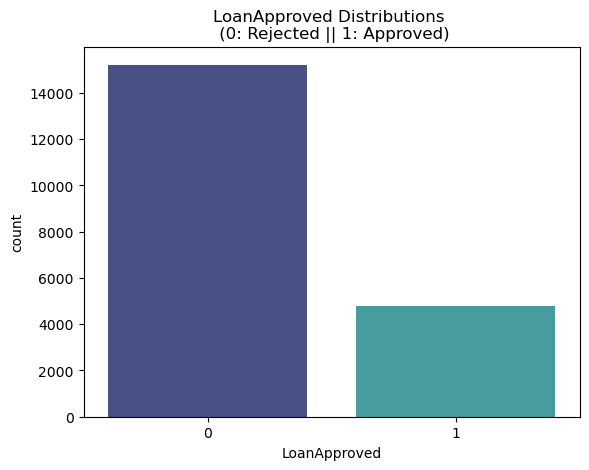

In [ ]:
sns.countplot(data=df_subset, x="LoanApproved", palette='mako')
plt.title('LoanApproved Distributions \n (0: Rejected || 1: Approved)')
plt.show()

We'll create a dataset such that the number of samples of loans approved and rejected are the same.

We see that the original dataset is highly imbalanced hence, will lead to biased results. \
If we continue to use the same dataset, we will face issues like Overfitting on training our machine learning models.

We have 4780 Approved Loan Applications in the total dataset, out of which, 2868 are in train dataset. \
Since we have 2868 Approved Loan applications in X_train, we need to randomly pick 2868 Rejected Loan applications. \
We also need to encode non numerical columns and normalize the dataset.

We will now randomly select the number of  Loan Rejected records to match the number of Loan Approved records

In [28]:
# Let's shuffle the dataset first
X_y_train = pd.concat([X_train,y_train.set_index(X_train.index)], axis = 1)

X_y_train = X_y_train.sample(frac = 1) # shuffling the data

# Separately extract Approved and Rejected rows
X_y_approved = X_y_train[X_y_train['LoanApproved'] == 1]
X_y_rejected = X_y_train[X_y_train['LoanApproved'] == 0][:X_y_approved.shape[0]] # selecting the same number of rows

X_y_concat = pd.concat([X_y_approved, X_y_rejected], axis = 0)
X_train = X_y_concat.drop(columns=['LoanApproved'])
y_train = X_y_concat['LoanApproved']

In [29]:
X_y_concat.shape

(5736, 9)

Let's visualize the Loan distribution now **(we are currently looking at the X train dataset, not the entire dataset)**

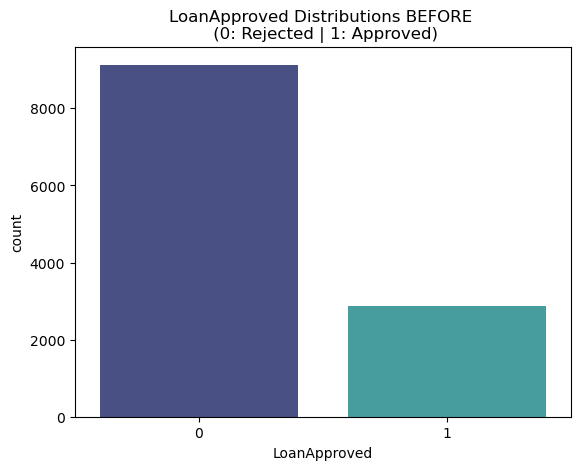

In [45]:
sns.countplot(data=X_y_train, x="LoanApproved", palette='mako')
plt.title('LoanApproved Distributions BEFORE \n (0: Rejected | 1: Approved)')
plt.show()

In [46]:
print("BEFORE")
print(f"Loan Requests Approved: {X_y_train[X_y_train['LoanApproved']==1].shape[0]}/{X_y_train.shape[0]}  =  {X_y_train[X_y_train['LoanApproved']==1].shape[0] / X_y_train.shape[0] * 100}%")
print(f"Loan Requests Rejected: {X_y_train[X_y_train['LoanApproved']==0].shape[0]}/{X_y_train.shape[0]}  =  {X_y_train[X_y_train['LoanApproved']==0].shape[0] / X_y_train.shape[0] * 100}%")

BEFORE
Loan Requests Approved: 2868/12000  =  23.9%
Loan Requests Rejected: 9132/12000  =  76.1%


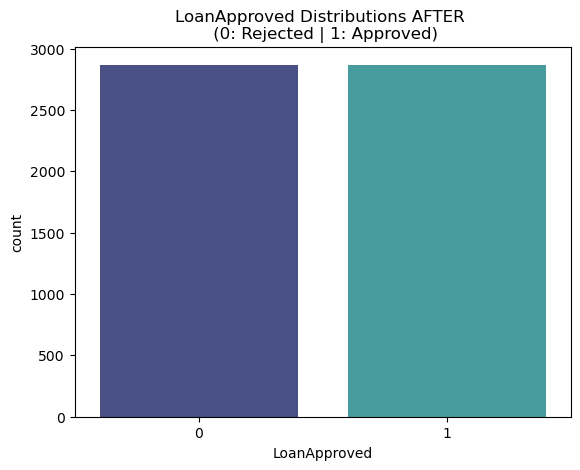

In [47]:
sns.countplot(data=X_y_concat, x="LoanApproved", palette='mako')
plt.title('LoanApproved Distributions AFTER \n (0: Rejected | 1: Approved)')
plt.show()

In [48]:
print("AFTER")
print(f"Loan Requests Approved: {X_y_concat[X_y_concat['LoanApproved']==1].shape[0]}/{X_y_concat.shape[0]}  =  {X_y_concat[X_y_concat['LoanApproved']==1].shape[0] / X_y_concat.shape[0] * 100}%")
print(f"Loan Requests Rejected: {X_y_concat[X_y_concat['LoanApproved']==0].shape[0]}/{X_y_concat.shape[0]}  =  {X_y_concat[X_y_concat['LoanApproved']==0].shape[0] / X_y_concat.shape[0] * 100}%")

AFTER
Loan Requests Approved: 2868/5736  =  50.0%
Loan Requests Rejected: 2868/5736  =  50.0%


#### Model Training

We'll be using 3 models - **Logistic Regression, Random Forest Classifier, and XG Boost**, to train on the subset and them compare their performances.

The evaluatrion metrics that we will be using are - **Precision, Recall, F1 Score and Confusion Matrix**

##### Helper Functions

I am defining 3 helper function to avoid code repetiton.

In [ ]:
# Function to train the model
# Input: model instance, X_train, y_train, X_val, y_val
# Output: trained model, classification report

def _model_training(model_type, X_tr, y_tr, X_val, y_val):
    model = model_type
    model.fit(X_tr, y_tr)
    y_val_pred = model.predict(X_val)

    cr = classification_report(y_val, y_val_pred)
    
    return model, cr

In [ ]:
# Function to test the classification performance of the model
# Input: Trained model, X_test, y_test
# Output: Classification report, Confusion Matrix

def _model_testing(model, X_te, y_te):
    y_pred = model.predict(X_te)
    cr = classification_report(y_te, y_pred)
    cm = confusion_matrix(y_test,y_pred)
    return cr, cm

In [ ]:
# Function to save the models
# Input: Trained model, File name

def _save_model(model, file_name):
    try:
        with open(f'{file_name}.pkl','wb') as f:
            pickle.dump(model,f)
            
        print("Model saved Successfully.")
        
    except OSError as e:
        print(f"!!Error Encountered!!:  {e}")

##### Logistic Regression model

In [ ]:
lr, cr = _model_training(LogisticRegression(), X_train, y_train, X_val, y_val)
print(cr)

              precision    recall  f1-score   support

           0       0.96      0.87      0.91      4870
           1       0.68      0.88      0.77      1530

    accuracy                           0.87      6400
   macro avg       0.82      0.87      0.84      6400
weighted avg       0.89      0.87      0.88      6400



In [43]:
cr, cm = _model_testing(lr, X_test, y_test)
print(cr)
print()
print("Confusion Matrix")
print(cm)

              precision    recall  f1-score   support

           0       0.95      0.86      0.90      1218
           1       0.66      0.86      0.75       382

    accuracy                           0.86      1600
   macro avg       0.81      0.86      0.83      1600
weighted avg       0.88      0.86      0.87      1600


Confusion Matrix
[[1050  168]
 [  54  328]]


##### Random Forest Classifier

In [ ]:
rf, cr = _model_training(RandomForestClassifier(), X_train, y_train, X_val, y_val)
print(cr)

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4870
           1       0.93      0.97      0.95      1530

    accuracy                           0.98      6400
   macro avg       0.96      0.98      0.97      6400
weighted avg       0.98      0.98      0.98      6400



In [45]:
cr, cm = _model_testing(rf, X_test, y_test)
print(cr)
print()
print("Confusion Matrix")
print(cm)

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1218
           1       0.93      0.98      0.96       382

    accuracy                           0.98      1600
   macro avg       0.96      0.98      0.97      1600
weighted avg       0.98      0.98      0.98      1600


Confusion Matrix
[[1190   28]
 [   7  375]]


##### XG Boost

In [40]:
# XG Boost
xg_boost, cr = _model_training(xgb.XGBClassifier(objective="binary:logistic"), X_train, y_train, X_val, y_val)
print(cr)

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4870
           1       0.95      0.98      0.96      1530

    accuracy                           0.98      6400
   macro avg       0.97      0.98      0.98      6400
weighted avg       0.98      0.98      0.98      6400



In [46]:
cr, cm = _model_testing(xg_boost, X_test, y_test)
print(cr)
print()
print("Confusion Matrix")
print(cm)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1218
           1       0.94      0.99      0.97       382

    accuracy                           0.98      1600
   macro avg       0.97      0.98      0.98      1600
weighted avg       0.98      0.98      0.98      1600


Confusion Matrix
[[1196   22]
 [   5  377]]


We can rank the overall performance of the models in the following order:      
XG Boost < Random Forest Classifier < Logistic Regression

We can see that **XG Boost** is our best performing model.

##### Saving Models and Datasets

In [ ]:
# save the models
_save_model(lr, 'log_reg')
_save_model(rf, 'random_forest')
_save_model(xg_boost, 'xg_boost')

In [48]:
df_subset.to_csv("Subset_data.csv", index=False )
X_y_concat.to_csv("Train data.csv", index=False)

In [51]:
X_test = pd.DataFrame(X_test)
y_test = pd.DataFrame(y_test)
X_y_test = pd.concat([X_test, y_test.set_index(X_test.index)], axis= 1)
X_y_test.columns = df_subset.columns
# X_y_test.head()
# print(X_test.shape, X_y_test.shape)
X_y_test.to_csv("Test data.csv", index=False)

In [52]:
X_val = pd.DataFrame(X_val)
y_val = pd.DataFrame(y_val)
X_y_val = pd.concat([X_val, y_val.set_index(X_val.index)], axis= 1)
X_y_val.columns = df_subset.columns
# print(X_test.shape, X_y_test.shape)
X_y_val.to_csv("Validation data.csv", index=False)